# Brasileirao Serie A (2016-2025) — Exploracao inicial

### 1. Carregando o dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
#index_col=0 impede que o pandas crie uma coluna extra de índice
df = pd.read_csv('campeonato-brasileiro-full.csv', index_col=0)
df.head()

,rodata,data,hora,mandante,visitante,formacao_mandante,formacao_visitante,tecnico_mandante,tecnico_visitante,vencedor,arena,mandante_Placar,visitante_Placar,mandante_Estado,visitante_Estado,arrecadacao
ID,,,,,,,,,,,,,,,,
1,1,29/03/2003,16:00,Guarani,Vasco,NaN,NaN,NaN,NaN,Guarani,Brinco de Ouro,4,2,SP,RJ,NaN
2,1,29/03/2003,16:00,Athletico-PR,Gremio,NaN,NaN,NaN,NaN,Athletico-PR,Arena da Baixada,2,0,PR,RS,NaN
3,1,30/03/2003,16:00,Flamengo,Coritiba,NaN,NaN,NaN,NaN,-,Maracanã,1,1,RJ,PR,NaN
4,1,30/03/2003,16:00,Goias,Paysandu,NaN,NaN,NaN,NaN,-,Serra Dourada,2,2,GO,PA,NaN
5,1,30/03/2003,16:00,Internacional,Ponte Preta,NaN,NaN,NaN,NaN,-,Beira Rio,1,1,RS,SP,NaN


In [2]:
#convertendo a coluna data de object para datetime pois usaremos apenas os ultimos 10 campeonatos
df['data'] = pd.to_datetime(df['data'], dayfirst=True)

#facilita o filtro por periodo
df['ano'] = df['data'].dt.year

df = df.loc[df['ano'] >= 2016]
df.head()

,rodata,data,hora,mandante,visitante,formacao_mandante,formacao_visitante,tecnico_mandante,tecnico_visitante,vencedor,arena,mandante_Placar,visitante_Placar,mandante_Estado,visitante_Estado,arrecadacao,ano
ID,,,,,,,,,,,,,,,,,
5368,1,2016-05-14,16:01,Flamengo,Sport,4-3-3,4-2-3-1,M. Ramalho,O. de Oliveira Filho,Flamengo,Estádio Municipal General Raulino de Oliveira,1,0,RJ,PE,NaN,2016
5367,1,2016-05-14,16:03,Palmeiras,Athletico-PR,4-2-3-1,4-2-3-1,A. Stival,P. Autuori de Mello,Palmeiras,Allianz Parque,4,0,SP,PR,NaN,2016
5369,1,2016-05-14,18:29,Atletico-MG,Santos,4-2-3-1,4-2-3-1,D. Aguirre Camblor,D. Silvestre Júnior,Atletico-MG,Estádio Raimundo Sampaio,1,0,MG,SP,NaN,2016
5370,1,2016-05-14,21:01,Coritiba,Cruzeiro,4-2-3-1,4-2-3-1,G. Kleina,G. Delamore,Coritiba,Couto Pereira,1,0,PR,MG,NaN,2016
5371,1,2016-05-15,11:00,Santa Cruz,Vitoria,4-2-3-1,4-2-3-1,E. Da Conceição Silva,V. Carmo Mancini,Santa Cruz,Estádio do Arruda,4,1,PE,BA,NaN,2016


### 2. Dimensões e estrutura

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3799 entries, 5368 to 9165
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   rodata              3799 non-null   int64         
 1   data                3799 non-null   datetime64[ns]
 2   hora                3799 non-null   object        
 3   mandante            3799 non-null   object        
 4   visitante           3799 non-null   object        
 5   formacao_mandante   3794 non-null   object        
 6   formacao_visitante  3794 non-null   object        
 7   tecnico_mandante    3798 non-null   object        
 8   tecnico_visitante   3798 non-null   object        
 9   vencedor            3799 non-null   object        
 10  arena               3799 non-null   object        
 11  mandante_Placar     3799 non-null   int64         
 12  visitante_Placar    3799 non-null   int64         
 13  mandante_Estado     3799 non-null   object        

In [4]:
df.describe()

,rodata,data,mandante_Placar,visitante_Placar,arrecadacao,ano
count,3799.000000,3799,3799.000000,3799.000000,3.800000e+02,3799.000000
mean,19.495130,2021-02-25 15:49:30.781784576,1.407739,0.977889,1.363330e+06,2020.530666
min,1.000000,2016-05-14 00:00:00,0.000000,0.000000,6.187500e+04,2016.000000
25%,10.000000,2018-08-22 00:00:00,1.000000,0.000000,4.731792e+05,2018.000000
50%,19.000000,2021-05-29 00:00:00,1.000000,1.000000,9.962582e+05,2021.000000
75%,29.000000,2023-08-19 00:00:00,2.000000,2.000000,1.916168e+06,2023.000000
max,38.000000,2025-12-07 00:00:00,8.000000,6.000000,5.983920e+06,2025.000000
std,10.964633,NaN,1.155317,0.989431,1.158877e+06,2.871946


In [5]:
df.shape

(3799, 17)

### 3. Valores nulos

In [6]:
df.isna().sum()

,0
rodata,0
data,0
hora,0
mandante,0
visitante,0
formacao_mandante,5
formacao_visitante,5
tecnico_mandante,1
tecnico_visitante,1
vencedor,0


### 4. Valores únicos

In [7]:
#total de temporadas no recorte
df['ano'].nunique()

10

In [8]:
#total de tecnicos unicos entre mandante e visitante
df[['tecnico_mandante', 'tecnico_visitante']].nunique().sum()

np.int64(497)

In [9]:
#total de clubes que participaram no periodo
df['mandante'].nunique()

34

### 5. Distribuicao de resultados
Vitorias do mandante, visitante e empates no periodo 2016-2025.

In [10]:
vitorias_mando = df[['mandante', 'visitante', 'vencedor']]

vitorias_mandante = vitorias_mando.loc[df['mandante'] == df['vencedor']]
vitorias_visitante = vitorias_mando.loc[df['visitante'] == df['vencedor']]
empates = vitorias_mando.loc[df['vencedor'] == '-']

In [11]:
print(len(vitorias_mandante))
print(len(vitorias_visitante))
print(len(empates))

1817
950
1032


In [12]:
total = len(vitorias_mandante) + len(vitorias_visitante) + len(empates)

print(f'Mandante: {len(vitorias_mandante) / total * 100:.1f}%')
print(f'Visitante: {len(vitorias_visitante) / total * 100:.1f}%')
print(f'Empate: {len(empates) / total * 100:.1f}%')

Mandante: 47.8%
Visitante: 25.0%
Empate: 27.2%


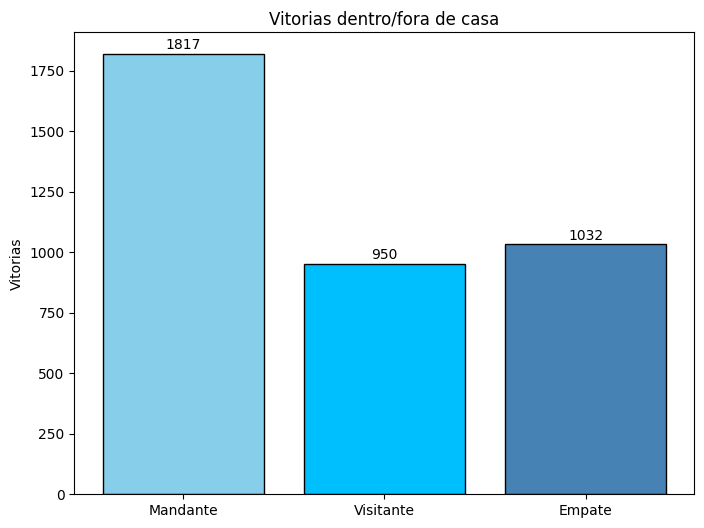

In [13]:
eixox = ['Mandante', 'Visitante', 'Empate']
eixoy = [len(vitorias_mandante), len(vitorias_visitante), len(empates)]
plt.figure(figsize=(8,6))
plt.title('Vitorias dentro/fora de casa')
plt.ylabel('Vitorias')
for i, valor in enumerate(eixoy):
    plt.text(i, valor + 20, str(valor), ha='center')
plt.bar(
        eixox,
        eixoy,
        color =['skyblue', 'deepskyblue', 'steelblue'],
        edgecolor ='black',
        )
plt.show()

### 6. Aproveitamento por clube
Top 5 clubes com mais vitorias no periodo.

In [14]:
top5 = df[df['vencedor'] != '-']['vencedor'].value_counts().head(5)
top5

,count
vencedor,
Palmeiras,210
Flamengo,206
Atletico-MG,164
Fluminense,149
Sao Paulo,147


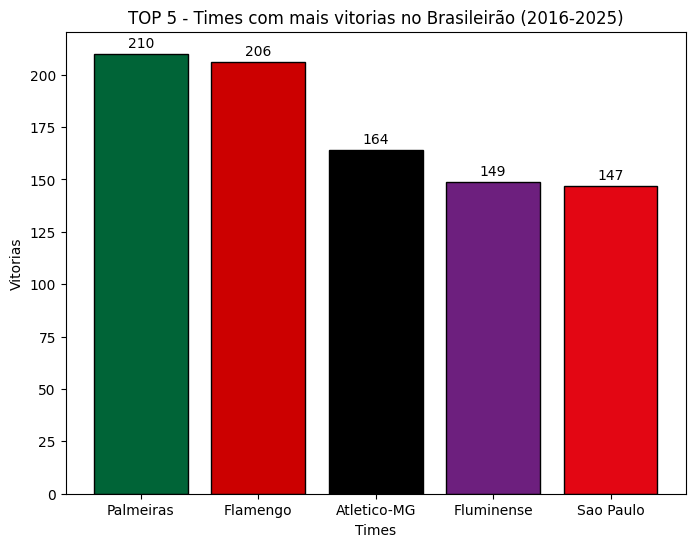

In [15]:
eixox = top5.index.tolist()
eixoy = top5.values.tolist()
plt.figure(figsize=(8,6))
plt.title('TOP 5 - Times com mais vitorias no Brasileirão (2016-2025)')
plt.xlabel('Times')
plt.ylabel('Vitorias')
for i, valor in enumerate(eixoy):
    plt.text(i, valor + 3, str(valor), ha='center')
plt.bar(
        eixox,
        eixoy,
        color =['#006437', '#CC0000', '#000000', '#6D1F7E', '#E30613'],
        edgecolor ='black',
        )
plt.show()

### 7. Conclusões

* O recorte cobre **10 temporadas** do Brasileirão Série A (2016-2025),
  com **3.799 partidas**, **34 clubes** diferentes e **497 técnicos**
  registrados entre mandante e visitante.

* O fator mando de campo e significativo: times mandantes venceram
  **1.817 partidas (47.8%)**, contra apenas **950 vitórias visitantes
  (25%)** e **1.032 empates (27.2%)**. Jogar em casa no Brasileirão
  quase dobra as chances de vitória.

* **Palmeiras e Flamengo** dominam o período com **210 e 206 vitórias**
  respectivamente, bem acima do terceiro colocado Atlético-MG com 164.
  Os dois clubes concentraram os principais títulos da década e isso
  se reflete diretamente na contagem de vitórias.

* O top 5 é composto exclusivamente por clubes do Sudeste, reforcando
  a concentração histórica do futebol brasileiro na região.